# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [2]:
files = {
    'sessions': ('session_time',),
    'riders': ('signup_date',),
    'drivers':('signup_date', 'last_active'),
    'trips': ('pickup_time', 'dropoff_time'),
    'promotions': ('start_date', 'end_date'),
}

dfs = {}
for name, date_cols in files.items():
    dfs[name] = pd.read_csv(f'../data/{name}.csv', parse_dates=list(date_cols))
    print(f'{name:10s}  {dfs[name].shape}')
    display(dfs[name].head())

sessions    (50000, 8)


,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


riders      (10000, 8)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


drivers     (5000, 7)


,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
2,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
3,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
4,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773


trips       (200000, 16)


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


promotions  (20, 11)


,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric
0,P000,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency
1,P001,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
2,P002,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-16,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
3,P003,Loyalty Bonus,points,100.0,2025-04-26,2025-05-04,Gold+,Nairobi,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
4,P004,Loyalty Bonus,points,100.0,2025-04-26,2025-05-15,Gold+,Nairobi,['All'],[1.0],Usage Frequency


### Basic Data Quality Check

In [3]:
# checking data quality
def data_quality_check(df, name):
    print(f'{name.upper()}')
    print(f'{"-" * 40}')
    print(f'Duplicate rows : {df.duplicated().sum()}')
    print(f'\nNull counts:')
    print(f'{df.isnull().sum().to_string()}\n')
    print(df.dtypes)
    print()
    
data = ['sessions', 'riders', 'drivers', 'trips', 'promotions']
for name in data:
    data_quality_check(dfs[name], name)

SESSIONS
----------------------------------------
Duplicate rows : 0

Null counts:
session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0

session_id        object
rider_id          object
session_time      object
time_on_app        int64
pages_visited      int64
converted          int64
city              object
loyalty_status    object
dtype: object

RIDERS
----------------------------------------
Duplicate rows : 0

Null counts:
user_id                0
signup_date            0
loyalty_status         0
age                    0
city                   0
avg_rating_given       0
churn_prob             0
referred_by         6947

user_id                     object
signup_date         datetime64[ns]
loyalty_status              object
age                        float64
city                        object
avg_rating_given           float64
churn_prob                 float64
referred_by   

### Investigating Session Data

In [4]:
sessions = dfs['sessions']
sessions[['time_on_app', 'pages_visited']].describe().round(2)

,time_on_app,pages_visited
count,50000.00,50000.00
mean,97.94,2.77
std,211.68,1.55
min,0.00,1.00
25%,12.00,1.00
50%,35.00,2.00
75%,90.00,4.00
max,1800.00,5.00


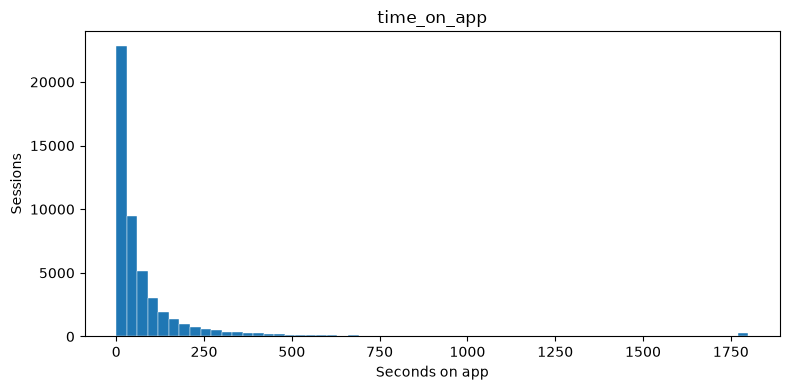

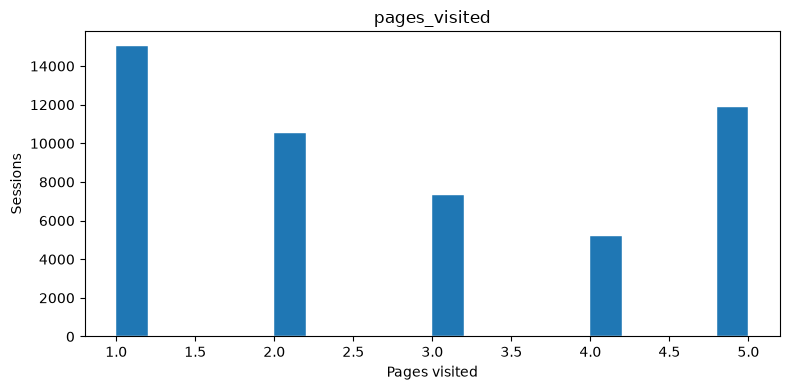

In [5]:
# checking numerical distribution
plt.figure(figsize=(8, 4))
plt.hist(sessions['time_on_app'], bins=60, edgecolor='white', linewidth=0.3)
plt.title('time_on_app')
plt.xlabel('Seconds on app')
plt.ylabel('Sessions')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(sessions['pages_visited'], bins=20, edgecolor='white', linewidth=0.3)
plt.title('pages_visited')
plt.xlabel('Pages visited')
plt.ylabel('Sessions')
plt.tight_layout()
plt.show()

### 1.3 Categorical Feature Breakdown

Here we look at how sessions are distributed across cities, loyalty tiers, and conversion outcomes.

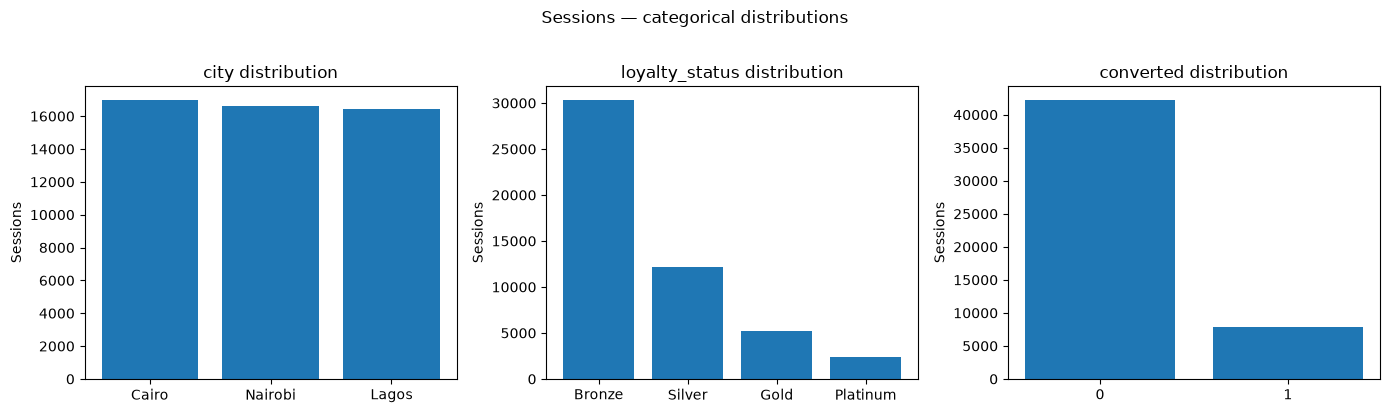

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['city', 'loyalty_status', 'converted']):
    vc = sessions[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values)
    ax.set_title(f'{col} distribution')
    ax.set_ylabel('Sessions')

plt.suptitle('Sessions — categorical distributions', y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Temporal Patterns: When Do Riders Open the App?

In [7]:
sessions['session_dt'] = pd.to_datetime(sessions['session_time'], utc=True)
sessions['hour_utc']   = sessions['session_dt'].dt.hour

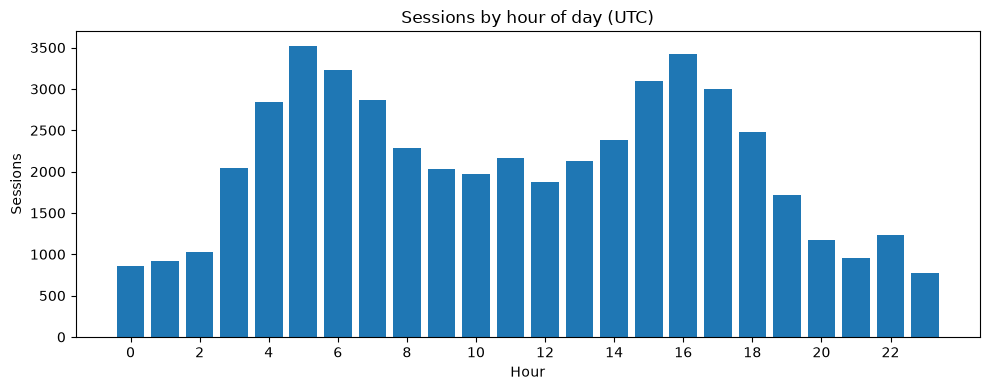

In [8]:
# Identifying app peak hours
hourly = sessions.groupby('hour_utc').size()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values)
plt.title('Sessions by hour of day (UTC)')
plt.xlabel('Hour')
plt.ylabel('Sessions')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


# **Basic Analysis**
- Do riders with higher churn risk have fewer trips?

### 6.1 Churn Risk vs Trip Frequency

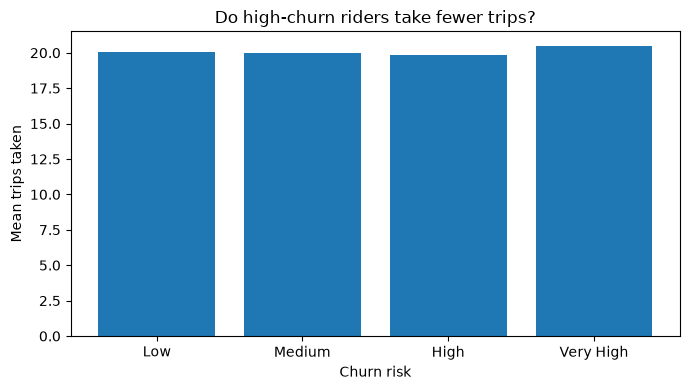

In [9]:
trips = dfs['trips']
riders = dfs['riders']

rider_trip_count = trips.groupby('user_id').size().reset_index(name='total_trips')
rider_joined = riders.merge(rider_trip_count, on='user_id', how='left')

rider_joined['churn_bucket'] = pd.cut(
    rider_joined['churn_prob'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

mean_trips = rider_joined.groupby('churn_bucket', observed=True)['total_trips'].mean()

plt.figure(figsize=(7, 4))
plt.bar(mean_trips.index, mean_trips.values)
plt.title('Do high-churn riders take fewer trips?')
plt.xlabel('Churn risk')
plt.ylabel('Mean trips taken')
plt.tight_layout()
plt.show()


### Correlation/linear relationship between independent and dependent

In [10]:
pd.set_option("display.max_columns", None)

trips = dfs['trips']
riders = dfs['riders']
sessions = dfs['sessions']
drivers = dfs['drivers']
promotions = dfs['promotions']

sessions.rename(columns = {
    'rider_id': 'user_id'
}, inplace = True)

merged = (trips.merge(riders, on='user_id', how='left')
.merge(sessions, on='user_id', how='left')
.merge(drivers, on='driver_id', how='left', suffixes=('_driver', '_rider')))

In [11]:
numeric_cols = merged.select_dtypes(include='float64').columns.tolist()
churn_corr = merged[numeric_cols].corr()['churn_prob'].drop('churn_prob').sort_values()

churn_corr

pages_visited      -0.003730
converted          -0.003654
avg_rating_given   -0.003537
acceptance_rate    -0.002387
rating             -0.002005
time_on_app        -0.001502
tip                -0.001150
pickup_lat         -0.000634
dropoff_lat        -0.000626
age                -0.000554
surge_multiplier    0.000160
fare                0.000277
hour_utc            0.003506
dropoff_lng         0.009446
pickup_lng          0.009449
Name: churn_prob, dtype: float64

### Features Selection using Mutual info Classification

In [12]:
merged['churn'] = (merged['churn_prob'] > 0.5).astype(int)

In [13]:
merged['session_time']

0          2025-04-27 17:06:11+02:27
1          2025-04-27 22:19:10+02:27
2          2025-04-27 00:07:25+02:27
3          2025-04-27 08:48:53+02:27
4          2025-04-27 01:05:16+00:14
                     ...            
1001269    2025-04-27 08:57:02+00:14
1001270    2025-04-27 08:02:15+02:05
1001271    2025-04-27 07:10:56+02:05
1001272    2025-04-27 10:20:53+02:05
1001273    2025-04-27 20:14:33+02:05
Name: session_time, Length: 1001274, dtype: object

In [14]:
merged.columns

Index(['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip',
       'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat',
       'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city_x',
       'loyalty_status_x', 'signup_date_driver', 'loyalty_status_y', 'age',
       'city_y', 'avg_rating_given', 'churn_prob', 'referred_by', 'session_id',
       'session_time', 'time_on_app', 'pages_visited', 'converted',
       'city_driver', 'loyalty_status', 'session_dt', 'hour_utc', 'rating',
       'vehicle_type', 'signup_date_rider', 'last_active', 'city_rider',
       'acceptance_rate', 'churn'],
      dtype='object')

In [15]:
from sklearn.feature_selection import mutual_info_classif

drop_cols = ['trip_id', 'user_id', 'driver_id', 'churn_prob',
    'pickup_time', 'dropoff_time', 'signup_date_rider', 'signup_date_driver',
    'session_time', 'session_id', 'referred_by', 'session_dt', 'last_active',]
feature_cols = [c for c in merged.columns if c not in drop_cols]

data = merged[feature_cols]
data = pd.get_dummies(data, columns=data.select_dtypes(include='object').columns.tolist(), dtype=int)

X = data.drop(columns='churn').fillna(data.drop(columns='churn').median())
y = data['churn']

X_sample = X.sample(n=50_000, random_state=42)
y_sample = y.loc[X_sample.index]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42, n_jobs=-1)
mi_series = pd.Series(mi_scores, index=X_sample.columns).sort_values(ascending=False)


In [16]:
print(mi_series)

age                          0.269749
dropoff_lat                  0.019626
pickup_lng                   0.018539
pickup_lat                   0.017598
dropoff_lng                  0.016288
acceptance_rate              0.007922
loyalty_status_x_Bronze      0.007540
loyalty_status_Bronze        0.006880
loyalty_status_y_Bronze      0.006616
weather_Sunny                0.006520
payment_type_Card            0.005948
vehicle_type_Sedan           0.005892
fare                         0.005449
time_on_app                  0.005315
payment_type_Mobile Money    0.004946
city_x_Lagos                 0.004319
city_x_Nairobi               0.004185
loyalty_status_Silver        0.004015
city_driver_Lagos            0.003386
city_y_Lagos                 0.003361
city_y_Nairobi               0.003239
city_y_Cairo                 0.003185
pages_visited                0.003171
surge_multiplier             0.003171
city_rider_Nairobi           0.003085
avg_rating_given             0.003049
city_driver_

In [17]:
zero_mi = mi_series[mi_series == 0].index.tolist()

selected = mi_series[mi_series > 0].index.tolist()

model_df = X[selected].copy()
model_df['churn'] = y.values
model_df.to_parquet('../data/model_input.parquet', index=False)
print(f"Saved {model_df.shape} → ../data/model_input.parquet")


Saved (1001274, 47) → ../data/model_input.parquet
